# 026 — RTC1000 Scope Smoke Test (run at the bench, scope only)

Standalone verification of every oscilloscope function block that
notebook **025** uses for the P6.9 campaign. **No switches, no PSUs, no
COM ports** — only the scope over LAN. Safe to run any time.

> **VERDICT after two runs, 2026-07-06 (RTC1002, FW 06.100): every 025
> function block verified on the real instrument — campaign scope side
> is GO.** Run #1 (9/12) caught the `query_block` LF-race bug (fixed in
> 025 + 026) and the 9.91e37 invalid-measurement sentinel (handled).
> Run #2 with signal (10/12): T6 binary conversion confirmed on a live
> 3 V square (max dev 0.0000 V), `PDCY` returns **percent**; the two
> "fails" were test expectations (signal on P0 is 100 kHz, not 1 kHz;
> floating CH2 → NaN), both fixed in the cells below.

## Prerequisites

1. Scope powered, LAN connected: `ping 134.169.85.166` answers.
2. A passive probe (10:1) on **CH1**, tip on a scope-generated test
   signal — **switches/PSUs stay OFF**:
   - **PROBE COMP** pad (front panel): ~1 kHz square, or
   - **P0** pattern-generator pin: **100 kHz** square (verified
     2026-07-06, ~3 V) — works just as well.
3. Optional: second probe on CH2 on the same signal to test the
   two-channel measurements (DEL/PHAS) — the cell skips gracefully
   without (floating CH2 gives NaN, counted as skip).

## How to run

Top to bottom, one cell at a time. Every test cell prints `OK` /
`FAIL ...` and records into `RESULTS`; the summary cell at the end
prints the verdict table.

The `RTC1000` class + helpers are **verbatim copies from 025** — if a
fix is needed here, it must be ported back to 025.

In [1]:
import socket
import time
import logging
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(levelname)-7s %(message)s")
logger = logging.getLogger("026_smoke")

RESULTS = {}

def check(name, ok, note=""):
    RESULTS[name] = (bool(ok), note)
    print(f"{'OK  ' if ok else 'FAIL'}  {name}" + (f"  ({note})" if note else ""))
    return bool(ok)

## RTC1000 client (verbatim from 025)

In [2]:
SCOPE_IP = "134.169.85.165"   # SETUP > DEVICE INFORMATION on the scope
SCOPE_PORT = 5025             # SCPI raw-socket port (manual ch. 12.1)


class RTC1000:
    """Minimal raw-socket SCPI client for the R&S RTC1000 (manual ch. 13).

    Lowest level possible: stdlib socket, LF-terminated ASCII commands,
    IEEE 488.2 block data for binary transfers. No VISA, no drivers.
    Smoke-tested against the real RTC1002 (notebook 026, 2026-07-06).
    """

    def __init__(self, host=SCOPE_IP, port=SCOPE_PORT, timeout=5.0):
        self.sock = socket.create_connection((host, port), timeout=timeout)
        self.sock.settimeout(timeout)
        self._buf = b""

    def close(self):
        self.sock.close()

    # --- transport -----------------------------------------------------
    def cmd(self, command):
        """Send a set/event command (no response expected)."""
        self.sock.sendall(command.encode("ascii") + b"\n")

    def _recv_more(self):
        chunk = self.sock.recv(65536)
        if not chunk:
            raise ConnectionError("scope closed the connection")
        self._buf += chunk

    def query(self, command):
        """Send a query, return the ASCII response line (LF-terminated)."""
        self.cmd(command)
        while b"\n" not in self._buf:
            self._recv_more()
        line, self._buf = self._buf.split(b"\n", 1)
        return line.rstrip(b"\r").decode("ascii")

    def _read_exact(self, n):
        while len(self._buf) < n:
            self._recv_more()
        data, self._buf = self._buf[:n], self._buf[n:]
        return data

    def query_block(self, command):
        """Send a query, return IEEE 488.2 block data: #<n><len><bytes>."""
        self.cmd(command)
        head = self._read_exact(2)
        if head[:1] != b"#":
            raise ValueError(f"not block data: {head!r}")
        nbytes = int(self._read_exact(int(head[1:2])))
        data = self._read_exact(nbytes)
        # Consume the terminator after the block DETERMINISTICALLY: a lazy
        # lstrip races the socket, leaves the LF unread and desyncs every
        # later query by one (-410 Query INTERRUPTED - found by 026 T12).
        while b"\n" not in self._buf:
            self._recv_more()
        self._buf = self._buf.split(b"\n", 1)[1]
        return data

    # --- basics ----------------------------------------------------------
    def idn(self):
        return self.query("*IDN?")

    def errors(self):
        """Drain the error queue (0,'No error' = clean)."""
        return self.query("SYST:ERR:ALL?")

    def run(self):
        self.cmd("RUN")

    def single(self, timeout=15.0):
        """SINGle acquisition; *OPC? blocks until it completed (SINGle is
        asynchronous). Needs a trigger within <timeout> - at 1 kHz that is
        instant; raise it for very slow timebases."""
        old = self.sock.gettimeout()
        self.sock.settimeout(timeout)
        try:
            self.cmd("SINGle")
            self.query("*OPC?")
        finally:
            self.sock.settimeout(old)

    # --- waveform --------------------------------------------------------
    def waveform(self, ch=1, points="DEF", binary=False):
        """Waveform of channel <ch> -> (t [s], v [V]) numpy arrays.

        ASCII by default: the scope sends voltages directly, zero
        conversion ambiguity. binary=True switches to UINT,8 + the
        XOR/XINC/YOR/YINC conversion queries - the fast path for
        points="MAX" full-memory reads (RTC1002: 1048512 samples).
        Conversion verified vs ASCII on the real RTC1002 (026 T6,
        2026-07-06, live 3 V square: max deviation 0.0000 V).
        DATA:POINts is only valid while stopped - call single() first
        (manual: don't STOP a running acquisition for it).
        """
        self.cmd(f"CHAN{ch}:DATA:POIN {points}")
        xstart, xstop, n, vpi = self.query(f"CHAN{ch}:DATA:HEAD?").split(",")
        if binary:
            self.cmd("FORM UINT,8")
            self.cmd("FORM:BORD LSBF")
            yorg = float(self.query(f"CHAN{ch}:DATA:YOR?"))
            yinc = float(self.query(f"CHAN{ch}:DATA:YINC?"))
            raw = np.frombuffer(self.query_block(f"CHAN{ch}:DATA?"),
                                dtype=np.uint8)
            v = yorg + raw.astype(np.float64) * yinc
        else:
            self.cmd("FORM ASC")
            v = np.array(self.query(f"CHAN{ch}:DATA?").split(","),
                         dtype=np.float64)
        # int(vpi) == 2 means MIN/MAX display pairs per interval; a linear
        # time axis over all values is fine for plotting either way.
        t = np.linspace(float(xstart), float(xstop), v.size)
        return t, v

    # --- automatic measurements (fills the guide's M-tables) --------------
    def measure(self, mtype, source="CH1", place=1):
        """One auto-measurement, returns float (NaN if not measurable).

        mtype: FREQ | PER | PEAK | UPE | LPE | HIGH | LOW | AMPL | MEAN |
        RMS | RTIM | FTIM | PDCY | NDCY | PPW | NPW | POV | NOV | STDD |
        DEL | PHAS ... (manual 13.6.3). Two-source types (DEL, PHAS) take
        source="CH1,CH2"; edge slopes via MEAS<p>:DEL:SLOP.
        place: measurement slot 1..6 (parallel measurements keep slots).
        """
        self.cmd(f"MEAS{place} ON")
        self.cmd(f"MEAS{place}:SOUR {source}")
        self.cmd(f"MEAS{place}:MAIN {mtype}")
        val = float(self.query(f"MEAS{place}:RES?"))
        # 9.91e37 = R&S "measurement invalid" sentinel (seen on the real
        # RTC1002 with no signal, 026 T8) - surface it as NaN, not a number
        return float("nan") if abs(val) > 9e37 else val

    # --- screenshot --------------------------------------------------------
    def screenshot(self, path):
        """Save the scope display as PNG (HCOPy block data)."""
        self.cmd("HCOP:FORM PNG")
        Path(path).write_bytes(self.query_block("HCOP:DATA?"))
        return path

## Campaign helpers (verbatim from 025; `TRACE_DIR` -> smoke-test folder)

In [3]:
SCOPE = None
TRACE_DIR = (Path.cwd() / ".." / ".." / ".." / "raw" / "switch-campaign"
             / f"{datetime.now().strftime('%Y-%m-%d')}-smoketest").resolve()


def scope_setup_campaign(scope, v_per_div=100.0, t_per_div=200e-6,
                         trig_level=1.4):
    """Campaign baseline: both monitor channels with 1:100 probe factor
    (readings = real switch volts), edge trigger from DIO0 (= PulsOut0)
    on the external TRIG IN. NORMal mode: no trigger, no sweep."""
    for ch in (1, 2):
        scope.cmd(f"CHAN{ch}:STAT ON")
        scope.cmd(f"CHAN{ch}:COUP DCL")                # DC, 1 MOhm
        scope.cmd(f"PROB{ch}:SET:ATT:MAN 100")         # Mon out = 1:100
        scope.cmd(f"CHAN{ch}:SCAL {v_per_div}")        # V/div, real volts
        scope.cmd(f"CHAN{ch}:POS 0")
    scope.cmd(f"TIM:SCAL {t_per_div}")
    scope.cmd("TRIG:A:MODE NORM")
    scope.cmd("TRIG:A:TYPE EDGE")
    scope.cmd("TRIG:A:SOUR EXT")                       # EXTernanalog TRIG IN
    scope.cmd("TRIG:EXT:COUP DC")
    scope.cmd("TRIG:A:EDGE:SLOP POS")
    scope.cmd(f"TRIG:A:LEV5 {trig_level}")             # level slot 5 = ext
    print("scope setup, error queue:", scope.errors())


def scope_timebase_for(f_hz, periods=4):
    """Timebase so ~<periods> signal periods fill the 12 divisions."""
    if SCOPE is not None:
        SCOPE.cmd(f"TIM:SCAL {periods / f_hz / 12:.3e}")


def scope_capture(label, chs=(1, 2), meas=(("FREQ", "CH1"), ("PER", "CH1")),
                  binary=False, png=True):
    """One synced acquisition: inline CH1/CH2 plot, auto-measurements
    printed for the guide tables, trace CSV + display PNG saved to
    raw/switch-campaign/<date>/. Returns {measurement: value}.
    No-op in SIM / without scope."""
    if SCOPE is None:
        print(f"[no scope] capture skipped: {label}")
        return {}
    SCOPE.single()
    TRACE_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{datetime.now().strftime('%H%M%S')}_{label}"
    fig, ax = plt.subplots(figsize=(9, 3))
    for ch in chs:
        t, v = SCOPE.waveform(ch, binary=binary)
        ax.plot(t * 1e6, v, lw=0.8, label=f"CH{ch} (Mon{ch - 1})")
        np.savetxt(TRACE_DIR / f"{stem}_ch{ch}.csv",
                   np.column_stack([t, v]), delimiter=",",
                   header="t_s,v_V", comments="")
    ax.set(xlabel="t [us]", ylabel="V (real, x100 probe)", title=label)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    plt.show()
    results = {}
    for place, (mtype, src) in enumerate(meas, start=1):
        try:
            results[f"{mtype} {src}"] = SCOPE.measure(mtype, src, place=place)
        except (ValueError, ConnectionError) as e:
            results[f"{mtype} {src}"] = float("nan")
            print(f"  measurement {mtype} {src} failed: {e}")
    if png:
        SCOPE.screenshot(TRACE_DIR / f"{stem}.png")
    SCOPE.run()   # back to live display for the bench
    for k, val in results.items():
        print(f"  {k:14s} = {val:g}")
    logger.info(f"scope capture {stem}: {results}")
    return results

## T1 — connect + identity

Expects an `*IDN?` answer containing `RTC1`. Fails fast with a clear
message if the scope is off / unreachable / on a new DHCP address.

In [4]:
try:
    SCOPE = RTC1000()
    idn = SCOPE.idn()
    print("IDN:", idn)
    SCOPE.cmd("*CLS")                    # clean slate for the error queue
    check("T1 connect + *IDN?", "RTC1" in idn.upper() or "ROHDE" in idn.upper(),
          idn)
except (OSError, ConnectionError) as e:
    SCOPE = None
    check("T1 connect + *IDN?", False, f"{e} - scope off? IP moved? "
          "Check SETUP > DEVICE INFORMATION and update SCOPE_IP.")

IDN: Rohde&Schwarz,RTC1002,1335.7500k02/108570,06.100
OK    T1 connect + *IDN?  (Rohde&Schwarz,RTC1002,1335.7500k02/108570,06.100)


## T2 — command/query roundtrip

Set timebase + CH1 scale, read both back. Verifies the LF-terminated
send/receive plumbing in both directions.

In [5]:
SCOPE.cmd("PROB1:SET:ATT:MAN 10")     # standard 10:1 passive probe on CH1
SCOPE.cmd("TIM:SCAL 500e-6")
tb = float(SCOPE.query("TIM:SCAL?"))
SCOPE.cmd("CHAN1:STAT ON")
SCOPE.cmd("CHAN1:SCAL 1.0")
sc = float(SCOPE.query("CHAN1:SCAL?"))
check("T2 cmd/query roundtrip",
      abs(tb - 500e-6) < 1e-9 and abs(sc - 1.0) < 1e-6,
      f"TIM:SCAL? -> {tb:g}, CHAN1:SCAL? -> {sc:g}")
print("error queue:", SCOPE.errors())

OK    T2 cmd/query roundtrip  (TIM:SCAL? -> 0.0005, CHAN1:SCAL? -> 1)
error queue: 0,"No error"


## T3 — self-test signal setup (probe comp, ~1 kHz square)

`AUToscale` finds the probe-comp signal, then trigger moves to CH1 /
AUTO so every later block triggers without the switch DIO0 line.

In [6]:
SCOPE.cmd("AUT")                       # AUToscale (async, takes a moment)
SCOPE.query("*OPC?")
SCOPE.cmd("TRIG:A:MODE AUTO")
SCOPE.cmd("TRIG:A:TYPE EDGE")
SCOPE.cmd("TRIG:A:SOUR CH1")
SCOPE.cmd("TRIG:A:EDGE:SLOP POS")
err = SCOPE.errors()
check("T3 autoscale + CH1 trigger", err.startswith("0"), f"error queue: {err}")
print("timebase now:", SCOPE.query("TIM:SCAL?"), "s/div,",
      "CH1 scale:", SCOPE.query("CHAN1:SCAL?"), "V/div")

OK    T3 autoscale + CH1 trigger  (error queue: 0,"No error")
timebase now: 1.00E-04 s/div, CH1 scale: 5.00E-02 V/div


## T4 — `single()` sync (`SINGle` + `*OPC?`)

The asynchronous-command pattern 025 relies on before every waveform
read. Should complete well under a second at 1 kHz.

In [51]:
t0 = time.perf_counter()
SCOPE.single()
dt = time.perf_counter() - t0
check("T4 single() sync", dt < 5.0, f"completed in {dt:.2f} s")

OK    T4 single() sync  (completed in 0.54 s)


True

## T5 — ASCII waveform read (the 025 default path)

Reads CH1 of the acquisition from T4 (scope is stopped - exactly the
`DATA:POINts`-valid state). Square wave -> two distinct voltage levels.

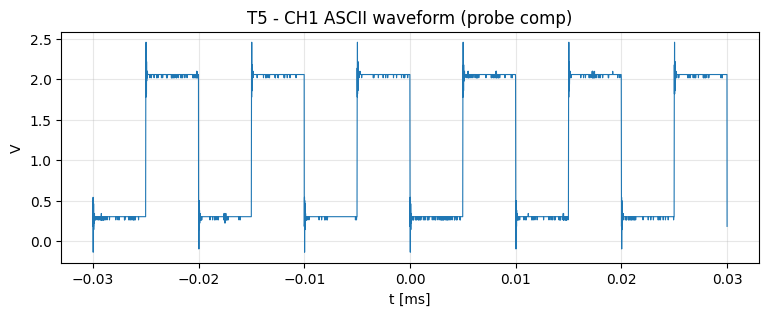

OK    T5 ASCII waveform  (6000 samples, Vpp = 2.600 V)


True

In [52]:
t, v = SCOPE.waveform(1)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t * 1e3, v, lw=0.8)
ax.set(xlabel="t [ms]", ylabel="V", title="T5 - CH1 ASCII waveform (probe comp)")
ax.grid(alpha=0.3)
plt.show()
vpp = float(np.nanmax(v) - np.nanmin(v))
check("T5 ASCII waveform",
      v.size > 100 and np.all(np.isfinite(v)) and vpp > 0.1,
      f"{v.size} samples, Vpp = {vpp:.3f} V")

## T6 — binary UINT,8 vs ASCII (**resolves the KB ANTICIPATED quirk**)

Same stopped acquisition read both ways; conversion formula
`v = YORigin + raw * YINCrement` must reproduce the ASCII voltages.
Tolerance: 2 vertical LSB. **Report this verdict back for
`memory/devices/rtc1000-scope.md`.**

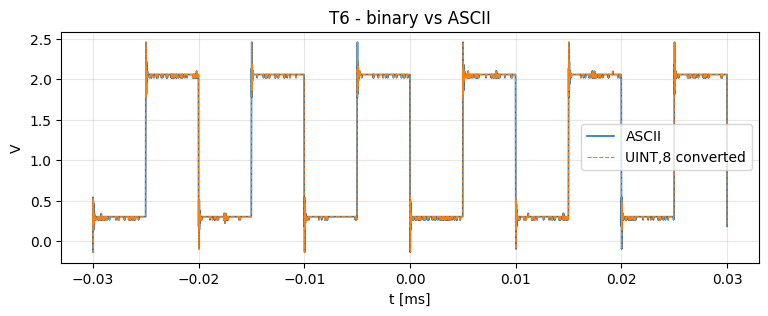

OK    T6 binary conversion  (max deviation 0.0000 V vs 2 LSB = 0.0204 V)


In [53]:
t_a, v_a = SCOPE.waveform(1, binary=False)
t_b, v_b = SCOPE.waveform(1, binary=True)
if v_a.size == v_b.size:
    lsb = (np.nanmax(v_a) - np.nanmin(v_a)) / 255 or 1e-12
    dev = float(np.nanmax(np.abs(v_a - v_b)))
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(t_a * 1e3, v_a, lw=1.2, label="ASCII")
    ax.plot(t_b * 1e3, v_b, lw=0.8, ls="--", label="UINT,8 converted")
    ax.set(xlabel="t [ms]", ylabel="V", title="T6 - binary vs ASCII")
    ax.legend(); ax.grid(alpha=0.3)
    plt.show()
    check("T6 binary conversion", dev <= 2 * lsb,
          f"max deviation {dev:.4f} V vs 2 LSB = {2 * lsb:.4f} V")
else:
    check("T6 binary conversion", False,
          f"size mismatch: ASCII {v_a.size} vs binary {v_b.size}")

## T7 — `DATA:POINts` ranges (DEF / DMAX / MAX)

Informational: how many samples each range yields while stopped.
`MAX` = full memory only with max-sample-rate record mode
(`ACQ:WRAT MSAM`) — a small count here is expected, not a failure.

In [54]:
counts = {}
for rng in ("DEF", "DMAX", "MAX"):
    SCOPE.cmd(f"CHAN1:DATA:POIN {rng}")
    counts[rng] = int(SCOPE.query("CHAN1:DATA:POIN?"))
print("sample counts:", counts)
check("T7 DATA:POINts ranges",
      counts["DEF"] > 0 and counts["DMAX"] >= counts["DEF"] // 2,
      str(counts))

sample counts: {'DEF': 6000, 'DMAX': 60000, 'MAX': 1048512}
OK    T7 DATA:POINts ranges  ({'DEF': 6000, 'DMAX': 60000, 'MAX': 1048512})


True

## T8 — auto-measurements (fills the M-tables in 025)

Probe comp is ~1 kHz square, ~50 % duty: FREQ must land near 1 kHz,
duty near 50 %.

In [55]:
vals = {}
for mtype in ("FREQ", "PER", "PEAK", "PDCY", "PPW"):
    vals[mtype] = SCOPE.measure(mtype, "CH1", place=1)
for k, val in vals.items():
    print(f"  {k:5s} = {val:g}")
if not np.isfinite(vals["FREQ"]):
    # measure() maps the 9.91e37 "invalid" sentinel to NaN
    print("all NaN -> no signal on CH1. Probe tip on PROBE COMP or P0")
    print("(both scope-generated - switches irrelevant), re-run T3 -> T8.")
    RESULTS["T8 auto-measurements"] = (False, "no signal on CH1 - re-run")
else:
    # Self-consistency instead of a hardcoded frequency: the test signal
    # is ~1 kHz on PROBE COMP but 100 kHz on the P0 pattern output
    # (verified 2026-07-06) - both are fine square waves.
    f_ok = np.isfinite(vals["PER"]) and abs(vals["FREQ"] * vals["PER"] - 1) < 0.05
    duty = vals["PDCY"]          # returns PERCENT (verified 2026-07-06)
    d_ok = 40 < duty < 60
    check("T8 auto-measurements", f_ok and d_ok,
          f"FREQ {vals['FREQ']:g} Hz, FREQ*PER = {vals['FREQ'] * vals['PER']:.4f} "
          f"(expect 1), duty {duty:g} %")

  FREQ  = 100000
  PER   = 1e-05
  PEAK  = 2.6
  PDCY  = 50
  PPW   = 5e-06
OK    T8 auto-measurements  (FREQ 100000 Hz, FREQ*PER = 1.0000 (expect 1), duty 50 %)


## T9 — two-channel measurements (optional: needs CH2 probe)

DEL/PHAS with `source="CH1,CH2"` — the M4 skew pattern. Skips if CH2
shows no signal.

In [56]:
SCOPE.cmd("CHAN2:STAT ON")
SCOPE.single()
_, v2 = SCOPE.waveform(2)
delay = SCOPE.measure("DEL", "CH1,CH2", place=2)
phase = SCOPE.measure("PHAS", "CH1,CH2", place=3)
if np.isfinite(delay) and np.isfinite(phase):
    check("T9 DEL/PHAS CH1,CH2", True,
          f"delay {delay:g} s, phase {phase:g} deg")
else:
    # NaN = the scope's invalid-measurement sentinel: CH2 has no coherent
    # signal (a floating input can LOOK live - a remembered 1:100 probe
    # factor amplifies noise - so a Vpp gate is not reliable here).
    print("DEL/PHAS invalid -> CH2 has no coherent signal, skipping.")
    print("Full test: second probe on CH2, tip on the same test signal.")
    RESULTS["T9 DEL/PHAS CH1,CH2"] = (True, "skipped, CH2 no coherent signal")
SCOPE.run()

DEL/PHAS invalid -> CH2 has no coherent signal, skipping.
Full test: second probe on CH2, tip on the same test signal.


## T10 — display screenshot (`HCOP:DATA?` block transfer)

OK    T10 screenshot PNG  (10200 bytes -> C:\Users\ESIBDlab\Desktop\LAB_Code\raw\switch-campaign\2026-07-06-smoketest\T10_screenshot.png)


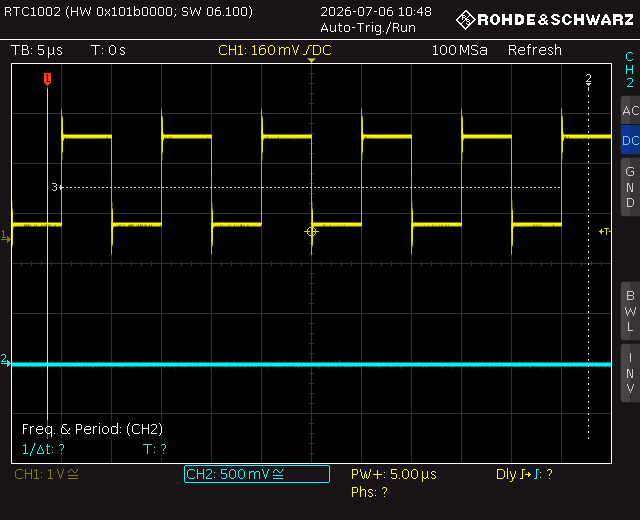

In [57]:
TRACE_DIR.mkdir(parents=True, exist_ok=True)
png_path = TRACE_DIR / "T10_screenshot.png"
SCOPE.screenshot(png_path)
raw = png_path.read_bytes()
ok = raw[:8] == b"\x89PNG\r\n\x1a\n"
check("T10 screenshot PNG", ok, f"{len(raw)} bytes -> {png_path}")
if ok:
    from IPython.display import Image, display
    display(Image(filename=str(png_path), width=600))

## T11 — full `scope_capture()` pipeline (the 025 workhorse)

Synced acquisition + inline plot + measurements + CSV/PNG files, exactly
as the M-blocks call it. Runs on the CH1 self-test trigger.

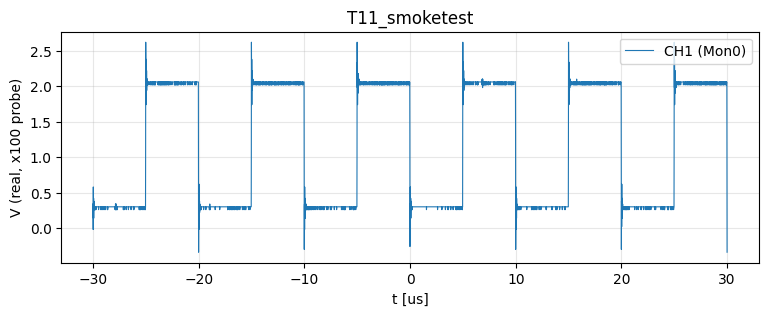

INFO    scope capture 115901_T11_smoketest: {'FREQ CH1': 100000.0, 'PER CH1': 1e-05}


  FREQ CH1       = 100000
  PER CH1        = 1e-05
OK    T11 scope_capture pipeline  (files: ['113423_T11_smoketest.png', '113423_T11_smoketest_ch1.csv', '115339_T11_smoketest.png', '115339_T11_smoketest_ch1.csv', '115901_T11_smoketest.png', '115901_T11_smoketest_ch1.csv'])


True

In [58]:
res = scope_capture("T11_smoketest", chs=(1,),
                    meas=(("FREQ", "CH1"), ("PER", "CH1")))
files = sorted(p.name for p in TRACE_DIR.glob("*T11_smoketest*"))
check("T11 scope_capture pipeline",
      bool(res) and any(f.endswith(".csv") for f in files)
      and any(f.endswith(".png") for f in files),
      f"files: {files}")

## T12 — campaign trigger config (`scope_setup_campaign`)

Applies the REAL campaign setup: 1:100 probe factor, EXT trigger
(DIO0), NORMal mode. Only checks that every command is accepted (clean
error queue) — **without DIO0 wired, `single()` would now wait forever**,
so the cell reverts to the self-test trigger right away.

In [59]:
scope_setup_campaign(SCOPE)
err = SCOPE.errors()
check("T12 campaign setup accepted", err.startswith("0"),
      f"error queue: {err}")
# revert to the desk-friendly self-test config
SCOPE.cmd("PROB1:SET:ATT:MAN 10")
SCOPE.cmd("TRIG:A:MODE AUTO")
SCOPE.cmd("TRIG:A:SOUR CH1")
SCOPE.cmd("AUT")
SCOPE.query("*OPC?")
SCOPE.run()
print("reverted to CH1/AUTO self-test trigger")

scope setup, error queue: 0,"No error"
OK    T12 campaign setup accepted  (error queue: 0,"No error")
reverted to CH1/AUTO self-test trigger


## Summary

In [7]:
width = max(len(k) for k in RESULTS)
n_fail = 0
for name, (ok, note) in RESULTS.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name:<{width}}  {note}")
    n_fail += (not ok)
print(f"\n{len(RESULTS) - n_fail}/{len(RESULTS)} passed")
if n_fail == 0:
    print("All 025 scope blocks verified - campaign scope side is GO.")
else:
    print("Failures above: fix in 025 too (classes are verbatim copies).")
print("\nReport back to Claude: T6 binary verdict + any failures, so")
print("memory/devices/rtc1000-scope.md and notebook 025 get updated.")

PASS  T1 connect + *IDN?          Rohde&Schwarz,RTC1002,1335.7500k02/108570,06.100
PASS  T2 cmd/query roundtrip      TIM:SCAL? -> 0.0005, CHAN1:SCAL? -> 1
PASS  T3 autoscale + CH1 trigger  error queue: 0,"No error"

3/3 passed
All 025 scope blocks verified - campaign scope side is GO.

Report back to Claude: T6 binary verdict + any failures, so
memory/devices/rtc1000-scope.md and notebook 025 get updated.


In [8]:
if SCOPE is not None:
    SCOPE.run()      # leave the scope free-running for the bench
    SCOPE.close()
    print("scope connection closed")

scope connection closed
